In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install geopandas cartopy shapely

In [3]:
import sys
import os
import xarray as xr
import numpy as np
import cartopy.crs as ccrs
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature

PROJECT_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection"
sys.path.insert(0, PROJECT_PATH)

In [4]:
from src.config import *
from src.climatology import *
from src.visualization import *
from src.ensemble import multi_model_mean

In [5]:
DATA_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/data/regridded"
BOUNDARY_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/data/boundaries/ne_10m_admin_0_countries.shp"
OUTPUT_PATH = "/content/drive/MyDrive/cmip6-madagascar-projection/data/processed"

os.makedirs(OUTPUT_PATH, exist_ok=True)

In [6]:
datasets_ts = []
datasets_pr = []

for model in MODELS:

    ts_file = os.path.join(
        DATA_PATH,
        f"{model}_ts_historical_regridded.nc"
    )

    pr_file = os.path.join(
        DATA_PATH,
        f"{model}_pr_historical_regridded.nc"
    )

    print("Loading :", model)

    ds_ts = xr.open_dataset(ts_file)
    ds_pr = xr.open_dataset(pr_file)

    # période climatologique standard
    ds_ts = ds_ts.sel(time=slice("1985", "2014"))
    ds_pr = ds_pr.sel(time=slice("1985", "2014"))

    datasets_ts.append(ds_ts)
    datasets_pr.append(ds_pr)

Loading : CNRM-CM6-1
Loading : IPSL-CM6A-LR
Loading : MPI-ESM1-2-LR


In [7]:
ts_mmm_hist = multi_model_mean(datasets_ts, "ts")
pr_mmm_hist = multi_model_mean(datasets_pr, "pr")

In [8]:
# Kelvin → Celsius
ts_mmm_hist = ts_mmm_hist - 273.15

# kg m-2 s-1 → mm/month
seconds_per_day = 86400
days_per_month = 30

pr_mmm_hist = pr_mmm_hist * seconds_per_day * days_per_month

In [9]:
ts_season = ts_mmm_hist.groupby("time.season").mean("time")
pr_season = pr_mmm_hist.groupby("time.season").mean("time")

ts_djf = ts_season.sel(season="DJF")
ts_jja = ts_season.sel(season="JJA")

pr_djf = pr_season.sel(season="DJF")
pr_jja = pr_season.sel(season="JJA")

Plotting historical climatology maps
Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/temperature_mean_africa.png


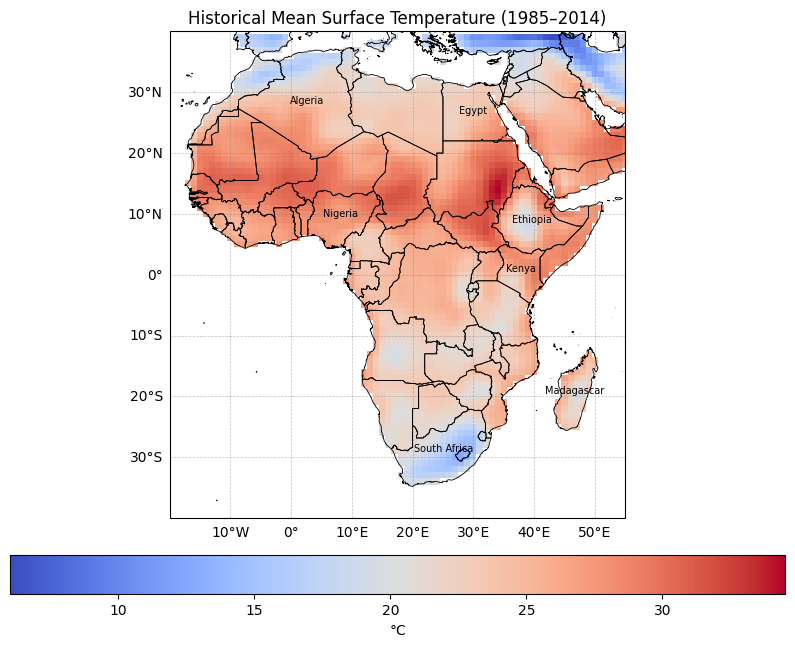

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/precipitation_mean_africa.png


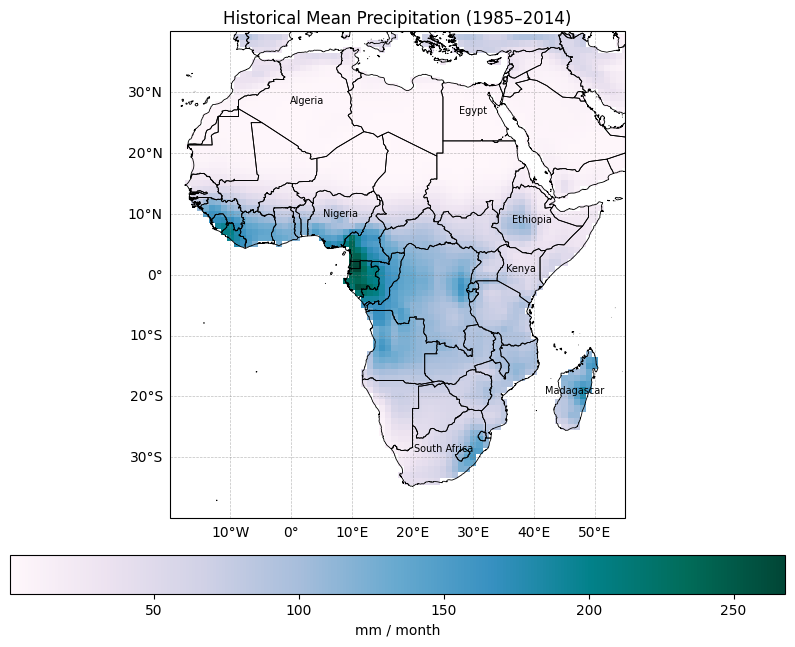

In [10]:
print("Plotting historical climatology maps")

plot_africa_map(
    ts_mmm_hist.mean("time"),
    "Historical Mean Surface Temperature (1985–2014)",
    cmap="coolwarm",
    save_name="temperature_mean_africa"
)

plot_africa_map(
    pr_mmm_hist.mean("time"),
    "Historical Mean Precipitation (1985–2014)",
    cmap="PuBuGn",
    save_name="precipitation_mean_africa"
)

Plotting seasonal maps
Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/temperature_DFJ_mean.png


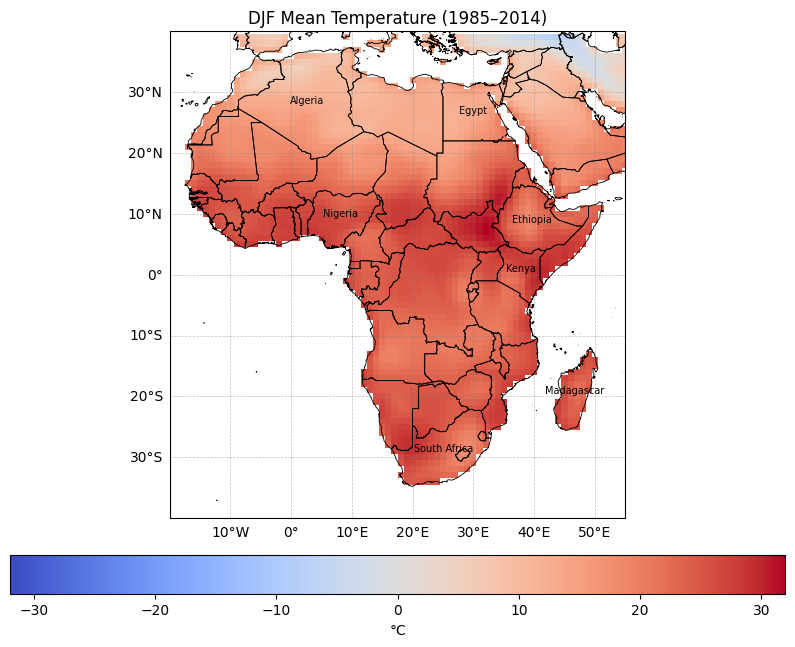

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/temperature_JJA_mean.png


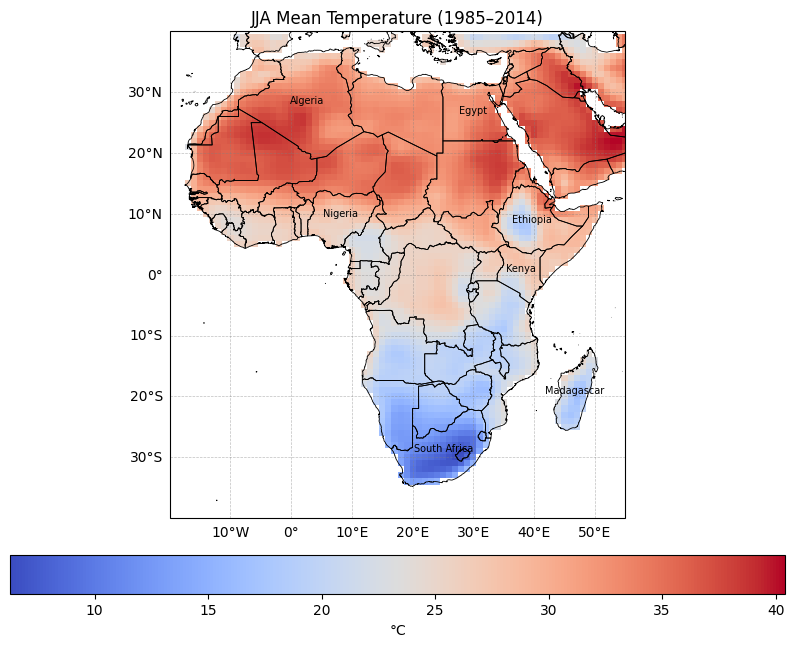

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/precipitation_DJF_mean.png


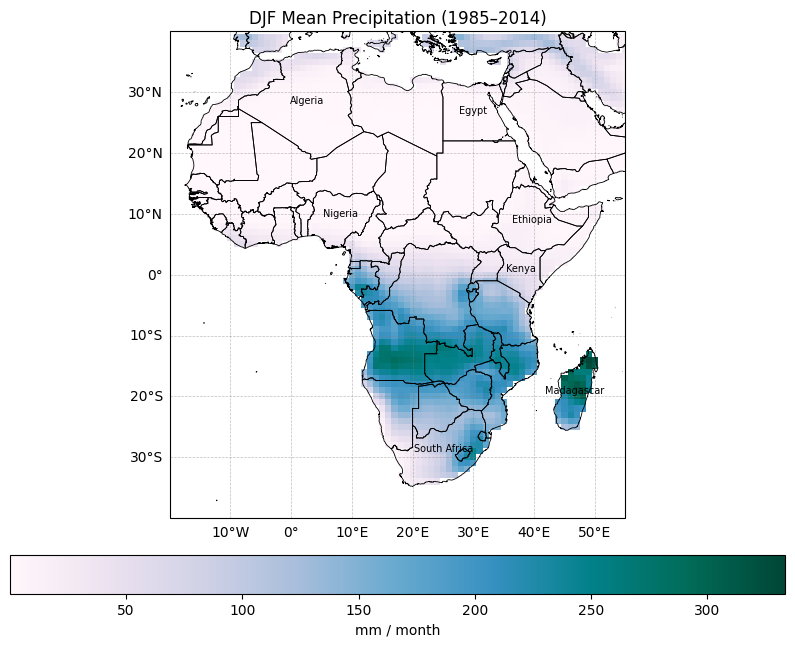

Figure saved : /content/drive/MyDrive/cmip6-madagascar-projection/outputs/figures/precipitation_JJA_mean.png


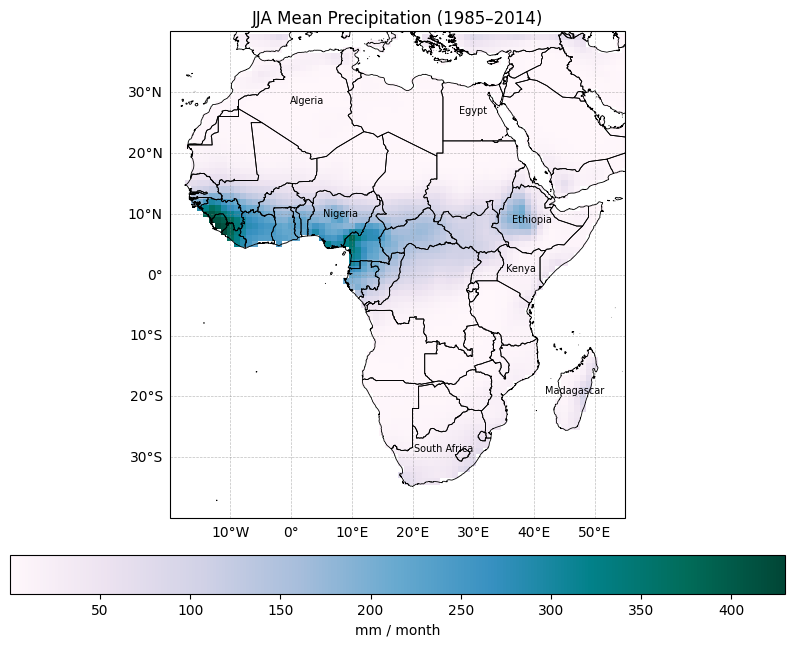

In [11]:
print("Plotting seasonal maps")

plot_africa_map(
    ts_djf,
    "DJF Mean Temperature (1985–2014)",
    cmap="coolwarm",
    save_name="temperature_DFJ_mean"
)

plot_africa_map(
    ts_jja,
    "JJA Mean Temperature (1985–2014)",
    cmap="coolwarm",
    save_name="temperature_JJA_mean"
)

plot_africa_map(
    pr_djf,
    "DJF Mean Precipitation (1985–2014)",
    cmap="PuBuGn",
    save_name="precipitation_DJF_mean"
)

plot_africa_map(
    pr_jja,
    "JJA Mean Precipitation (1985–2014)",
    cmap="PuBuGn",
    save_name="precipitation_JJA_mean"
)

In [12]:
ts_mmm_hist.to_netcdf(
    os.path.join(OUTPUT_PATH, "ts_MMM_historical.nc")
)

pr_mmm_hist.to_netcdf(
    os.path.join(OUTPUT_PATH, "pr_MMM_historical.nc")
)

ts_season.to_netcdf(
    os.path.join(OUTPUT_PATH, "ts_seasonal_historical.nc")
)

pr_season.to_netcdf(
    os.path.join(OUTPUT_PATH, "pr_seasonal_historical.nc")
)

print("\nHistorical analysis completed")


Historical analysis completed
